# EDA — ch_records_test.csv
## Análisis Exploratorio de Churn Bancario

Dataset con **10,000 clientes** y **18 variables**. El objetivo es entender qué perfil de cliente abandona el banco (`Exited = 1`) antes de entrenar el modelo predictivo.

| Campo | Detalle |
|---|---|
| Filas | 10,000 |
| Columnas | 18 |
| Target | `Exited` (1 = abandona, 0 = se queda) |
| Tasa de churn | ~20.4% |

## 1. Librerías e importación

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12

# Cargamos el dataset
df = pd.read_csv('../data/ch_records_test.csv')

# Eliminamos columnas que no aportan información predictiva
# RowNumber y CustomerId son IDs técnicos; Surname es texto libre sin valor estadístico
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Filas: 10,000 | Columnas: 15


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 2. Estructura y calidad del dataset

In [8]:
# Tipos de dato — las categóricas necesitarán encoding antes del modelo
print('Tipos de dato:')
print(df.dtypes)
print()

# Verificamos valores nulos — este dataset no tiene, pero siempre hay que confirmarlo
nulos = df.isnull().sum()
print('Valores nulos:', 'Ninguno ✓' if nulos.sum() == 0 else nulos[nulos > 0])

Tipos de dato:
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object

Valores nulos: Ninguno ✓


In [9]:
# Estadísticas descriptivas — detectamos rangos, outliers y distribuciones anómalas
df.describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.0,10000.00,10000.00
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2,0.2,3.01,606.52
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4,0.4,1.41,225.92
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0,0.0,1.00,119.00
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0,0.0,2.00,410.00
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0,0.0,3.00,605.00
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0,0.0,4.00,801.00
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0,1.0,5.00,1000.00


In [10]:
# Valores únicos por variable categórica
cats = ['Geography', 'Gender', 'Card Type']
for col in cats:
    print(f'{col}: {df[col].unique()}')

Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']
Card Type: ['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']


## 3. Variable target: Exited

Analizamos el balance del dataset. Con ~20% de churn tenemos un desbalance moderado — manejable sin técnicas agresivas de oversampling.

Se queda (0): 7,962  (79.6%)
Abandona (1): 2,038  (20.4%)


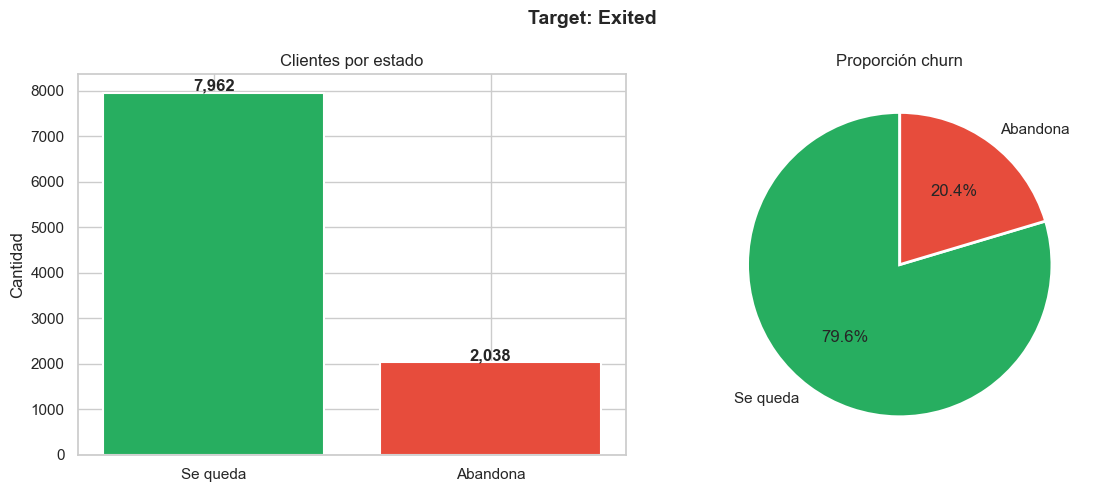

In [11]:
conteo = df['Exited'].value_counts()
pct    = df['Exited'].value_counts(normalize=True) * 100

print(f'Se queda (0): {conteo[0]:,}  ({pct[0]:.1f}%)')
print(f'Abandona (1): {conteo[1]:,}  ({pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras con cantidad absoluta
axes[0].bar(['Se queda', 'Abandona'], conteo.values,
            color=['#27ae60', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Clientes por estado')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Torta con porcentaje
axes[1].pie(conteo.values, labels=['Se queda', 'Abandona'],
            colors=['#27ae60', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción churn')

plt.suptitle('Target: Exited', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Churn por variables categóricas

Identificamos qué segmentos presentan mayor riesgo de abandono.

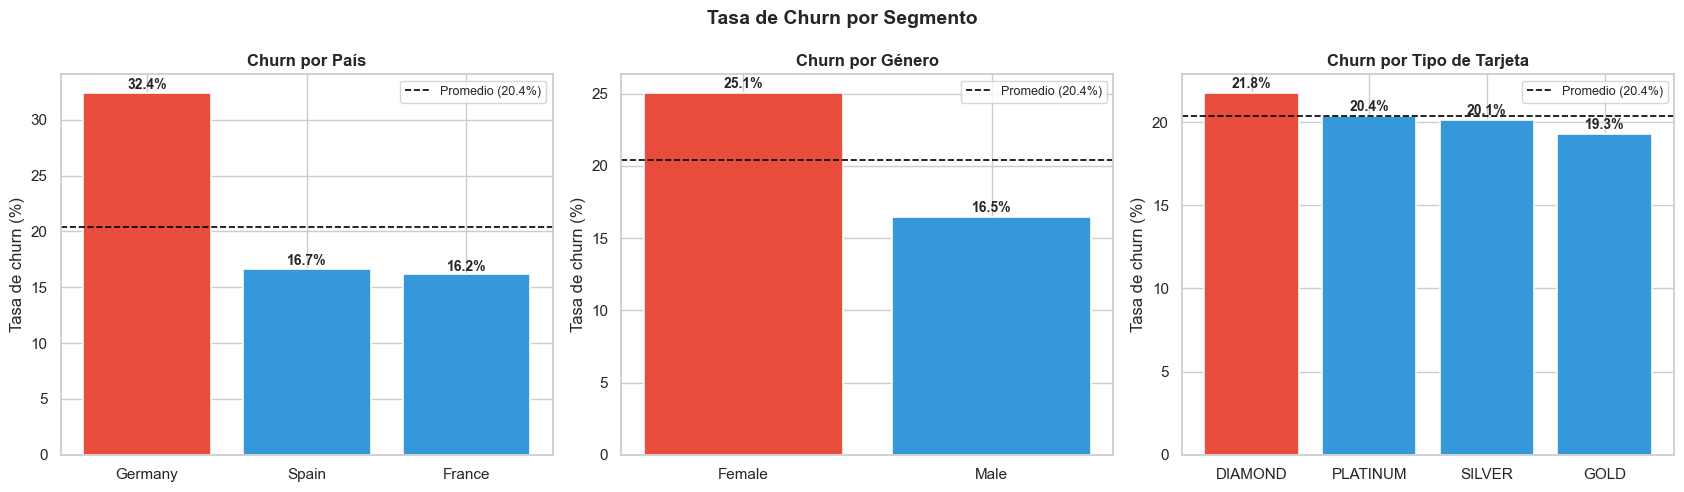

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Función: calcula tasa de churn por categoría y grafica barras comparativas
def barras_churn(col, titulo, ax):
    tasa = df.groupby(col)['Exited'].mean().sort_values(ascending=False) * 100
    colores = ['#e74c3c' if v > df['Exited'].mean() * 100 else '#3498db' for v in tasa.values]
    bars = ax.bar(tasa.index, tasa.values, color=colores, edgecolor='white', linewidth=1.2)
    ax.axhline(df['Exited'].mean() * 100, color='black', linestyle='--',
               linewidth=1.2, label=f'Promedio ({df["Exited"].mean()*100:.1f}%)')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Tasa de churn (%)')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, tasa.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

barras_churn('Geography', 'Churn por País',         axes[0])
barras_churn('Gender',    'Churn por Género',        axes[1])
barras_churn('Card Type', 'Churn por Tipo de Tarjeta', axes[2])

plt.suptitle('Tasa de Churn por Segmento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

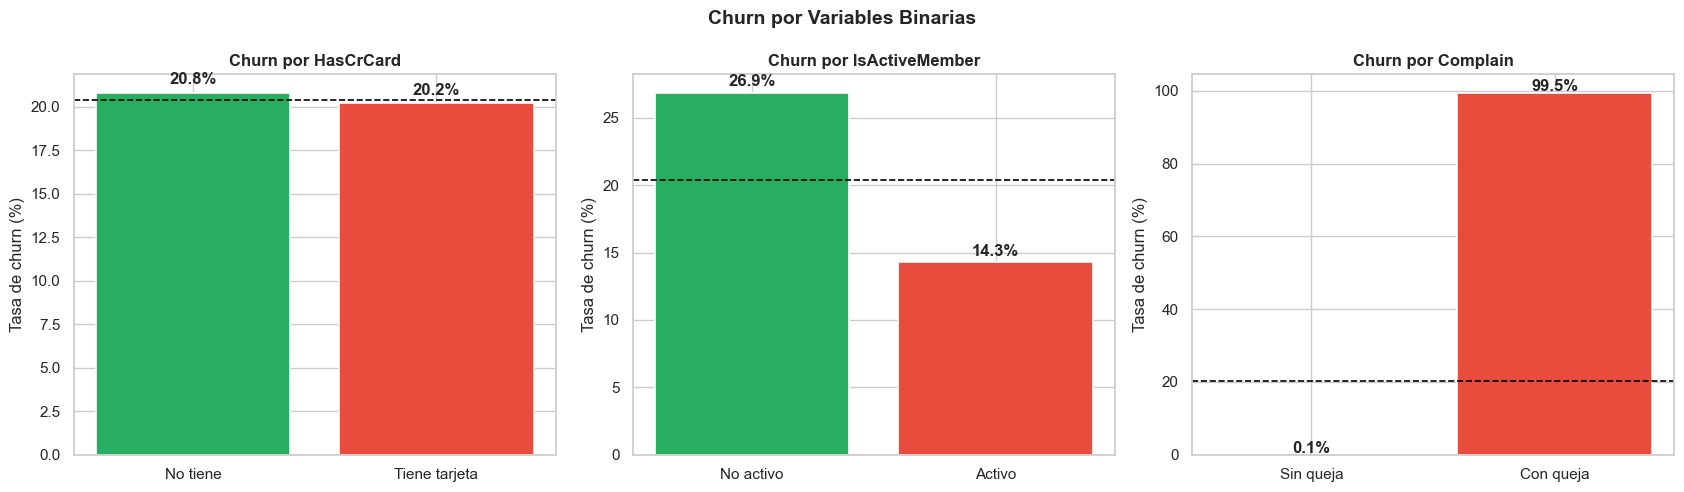

In [13]:
# Variables binarias: HasCrCard, IsActiveMember, Complain
# Estas son 0/1 pero las tratamos como categóricas para ver la tasa de churn
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

binarias = {
    'HasCrCard':     ('No tiene', 'Tiene tarjeta'),
    'IsActiveMember':('No activo', 'Activo'),
    'Complain':      ('Sin queja', 'Con queja'),
}

for ax, (col, (label0, label1)) in zip(axes, binarias.items()):
    tasa = df.groupby(col)['Exited'].mean() * 100
    colores = ['#27ae60' if i == 0 else '#e74c3c' for i in tasa.index]
    bars = ax.bar([label0, label1], tasa.values, color=colores, edgecolor='white', linewidth=1.2)
    ax.axhline(df['Exited'].mean() * 100, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(f'Churn por {col}', fontweight='bold')
    ax.set_ylabel('Tasa de churn (%)')
    for bar, val in zip(bars, tasa.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Churn por Variables Binarias', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Distribución de variables numéricas: activos vs abandona

Si las distribuciones de una variable difieren entre churn=0 y churn=1, esa variable tiene poder predictivo.

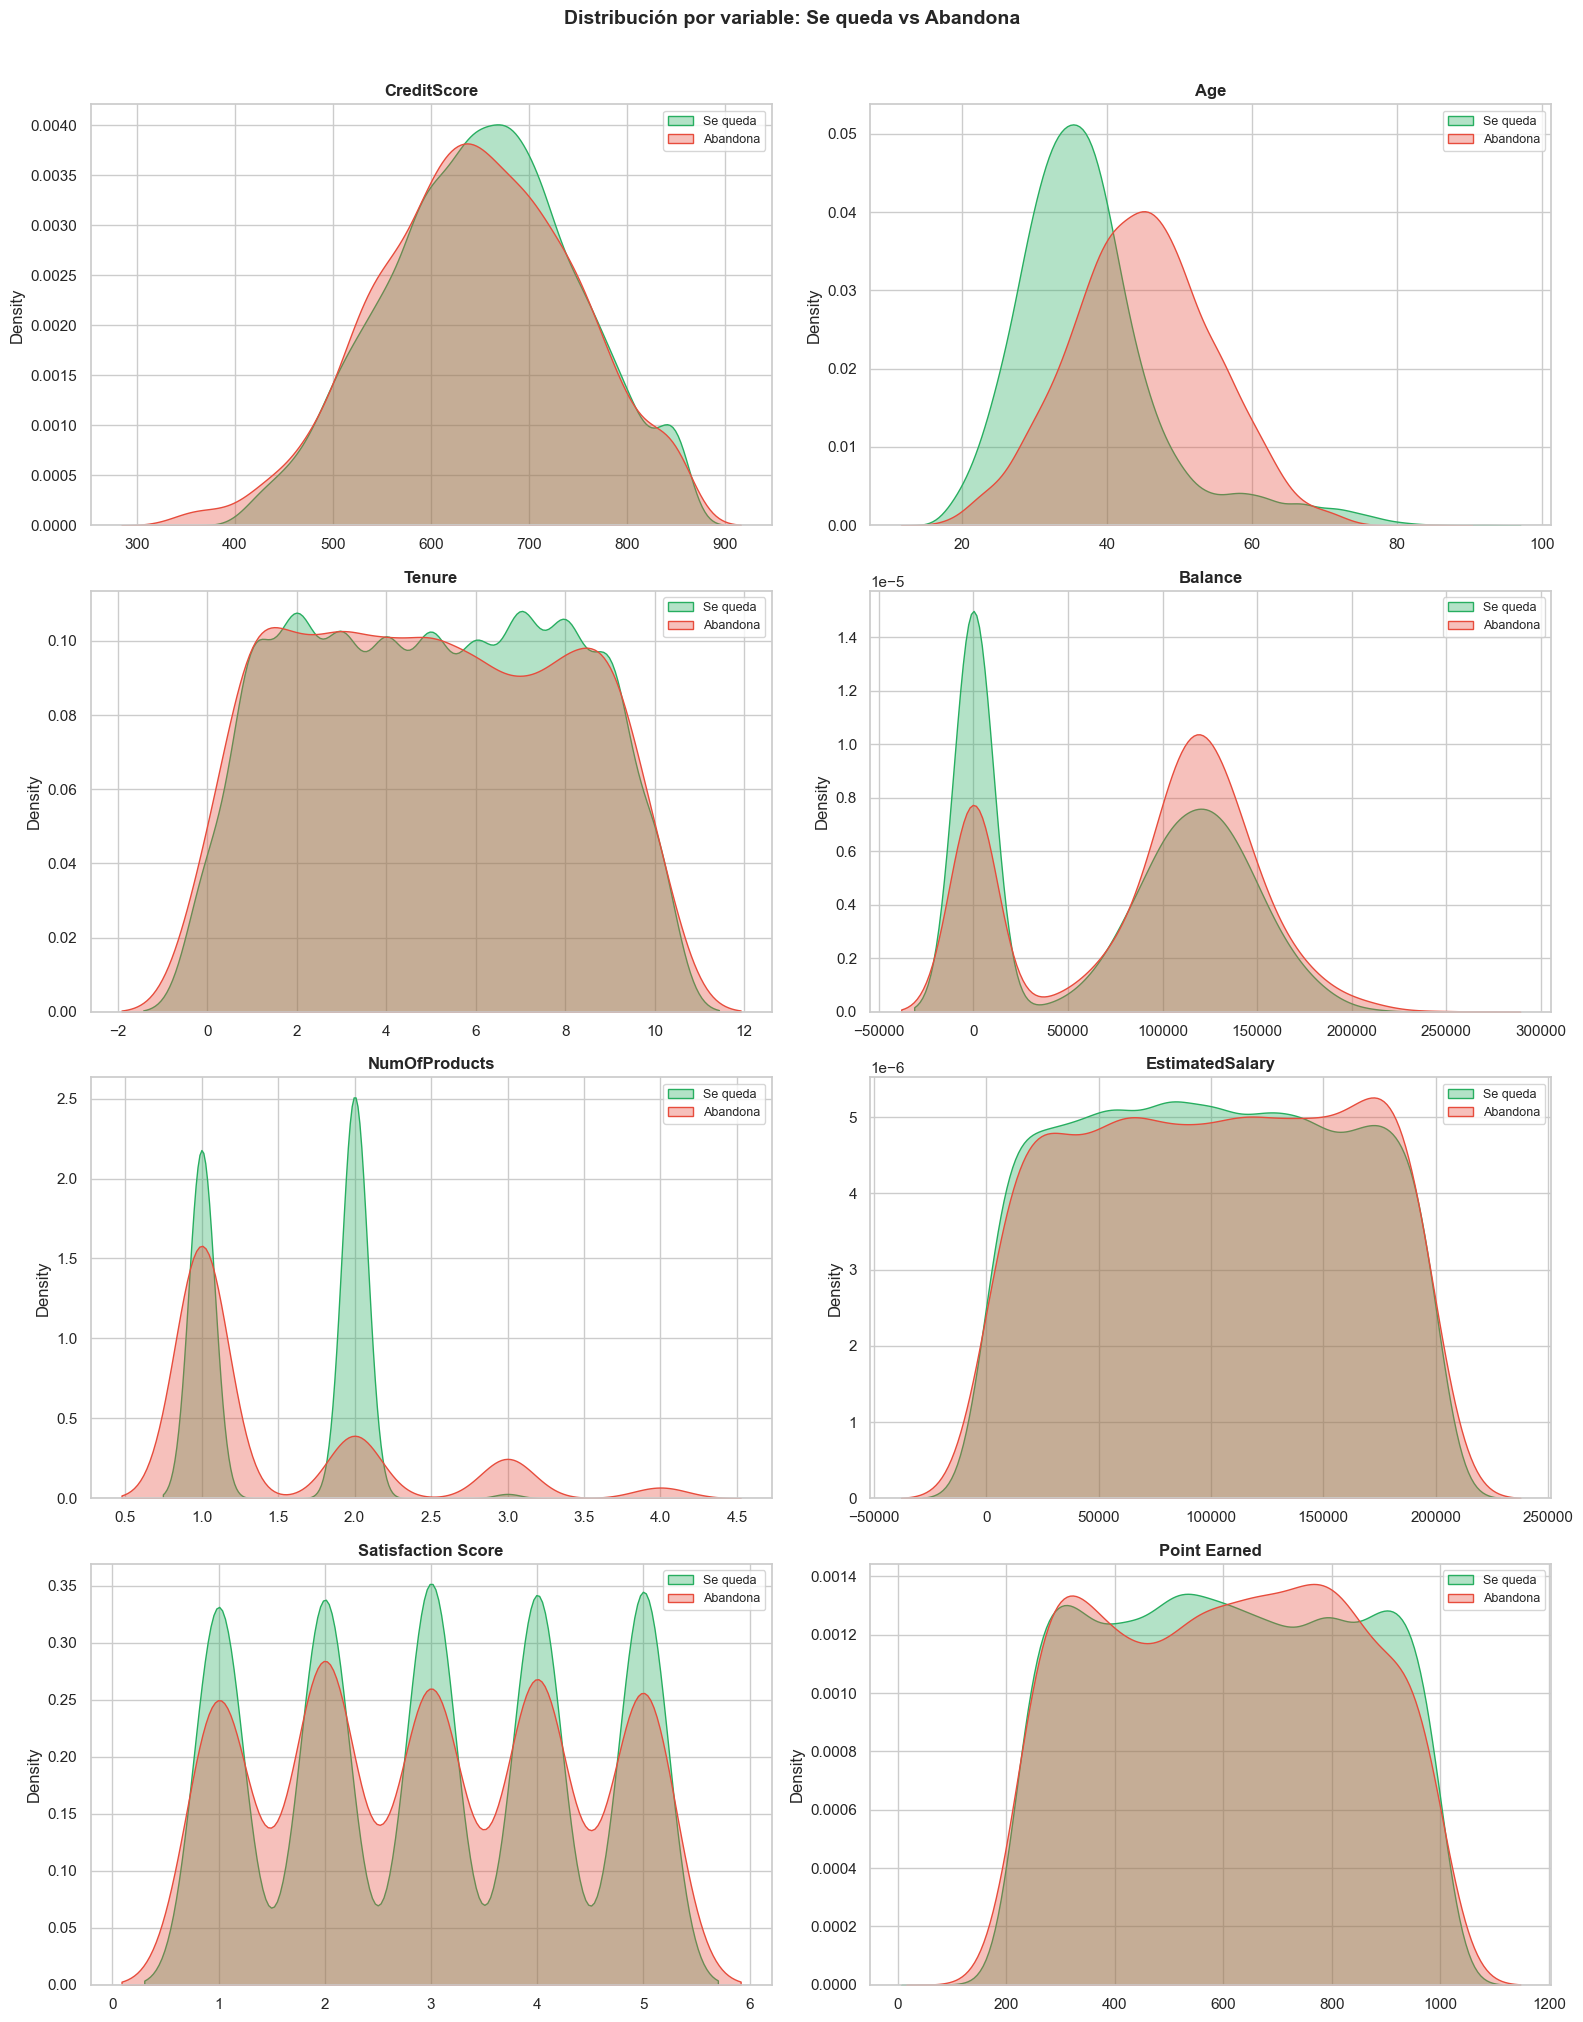

In [14]:
vars_num = ['CreditScore', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, var in enumerate(vars_num):
    # Superponemos densidad de churn=0 vs churn=1
    # Si las curvas se separan = variable predictiva
    for val, color, label in [(0, '#27ae60', 'Se queda'), (1, '#e74c3c', 'Abandona')]:
        sns.kdeplot(
            df[df['Exited'] == val][var],
            ax=axes[idx], color=color, label=label, fill=True, alpha=0.35
        )
    axes[idx].set_title(var, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].set_xlabel('')

plt.suptitle('Distribución por variable: Se queda vs Abandona', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Churn por edad — el predictor más visual

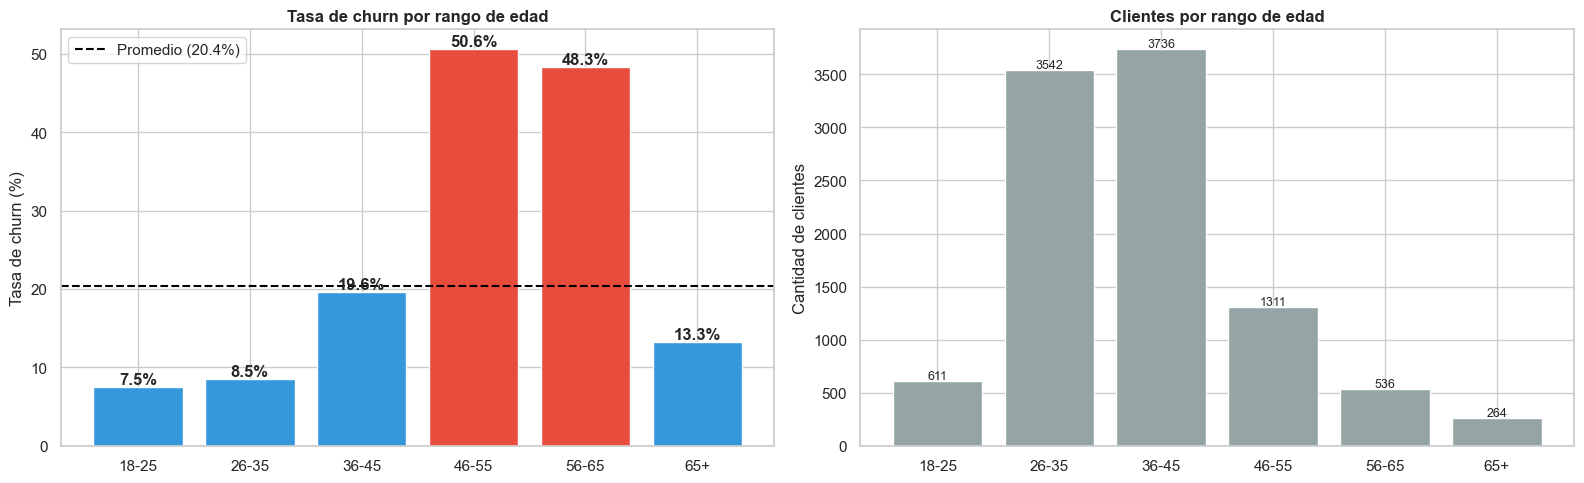

In [15]:
# Agrupamos la edad en rangos para ver la tasa de churn en cada grupo
bins   = [17, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

churn_edad = df.groupby('age_group', observed=True)['Exited'].mean() * 100
total_edad = df.groupby('age_group', observed=True)['Exited'].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Tasa de churn por rango de edad
colores = ['#e74c3c' if v > df['Exited'].mean() * 100 else '#3498db' for v in churn_edad.values]
bars = axes[0].bar(churn_edad.index, churn_edad.values, color=colores, edgecolor='white')
axes[0].axhline(df['Exited'].mean() * 100, color='black', linestyle='--',
                linewidth=1.5, label=f'Promedio ({df["Exited"].mean()*100:.1f}%)')
axes[0].set_title('Tasa de churn por rango de edad', fontweight='bold')
axes[0].set_ylabel('Tasa de churn (%)')
axes[0].legend()
for bar, val in zip(bars, churn_edad.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.4,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Cantidad de clientes por rango (para contextualizar el tamaño de muestra)
axes[1].bar(total_edad.index, total_edad.values, color='#95a5a6', edgecolor='white')
axes[1].set_title('Clientes por rango de edad', fontweight='bold')
axes[1].set_ylabel('Cantidad de clientes')
for i, v in enumerate(total_edad.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

df.drop(columns=['age_group'], inplace=True)

## 7. Churn por número de productos

`NumOfProducts` suele tener un comportamiento no lineal — clientes con 1 producto y con 3-4 productos tienen patrones distintos.

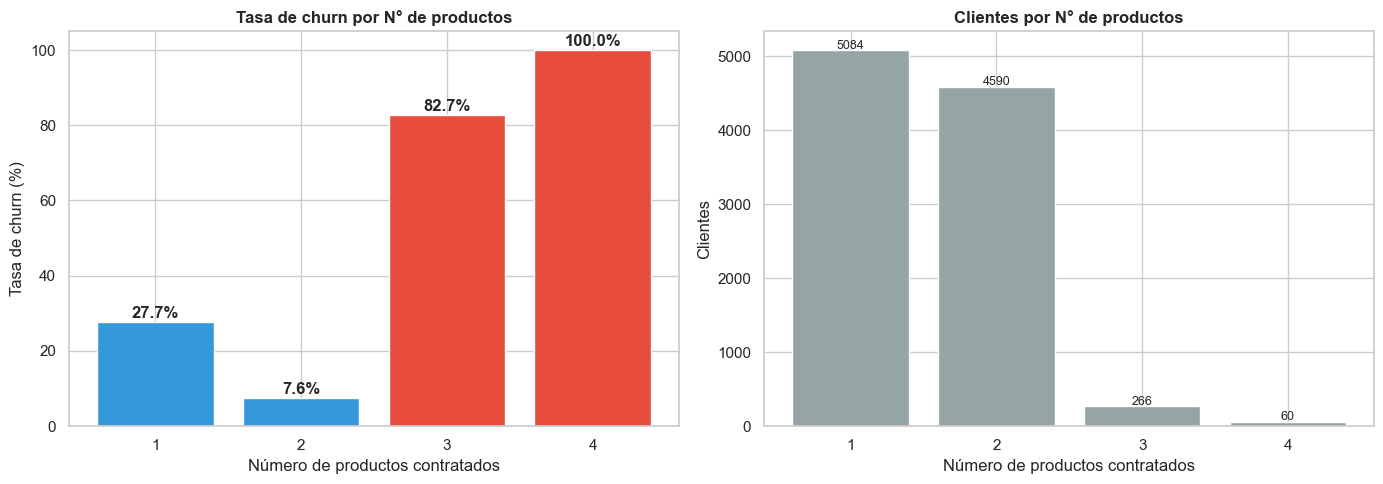

In [16]:
churn_prod  = df.groupby('NumOfProducts')['Exited'].mean() * 100
total_prod  = df.groupby('NumOfProducts')['Exited'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de churn — esperamos patrón en U o J
axes[0].bar(churn_prod.index.astype(str), churn_prod.values,
            color=['#e74c3c' if v > 30 else '#3498db' for v in churn_prod.values],
            edgecolor='white')
axes[0].set_title('Tasa de churn por N° de productos', fontweight='bold')
axes[0].set_xlabel('Número de productos contratados')
axes[0].set_ylabel('Tasa de churn (%)')
for i, (idx, val) in enumerate(churn_prod.items()):
    axes[0].text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

# Volumen por grupo para contextualizar
axes[1].bar(total_prod.index.astype(str), total_prod.values, color='#95a5a6', edgecolor='white')
axes[1].set_title('Clientes por N° de productos', fontweight='bold')
axes[1].set_xlabel('Número de productos contratados')
axes[1].set_ylabel('Clientes')
for i, v in enumerate(total_prod.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Satisfaction Score vs Churn

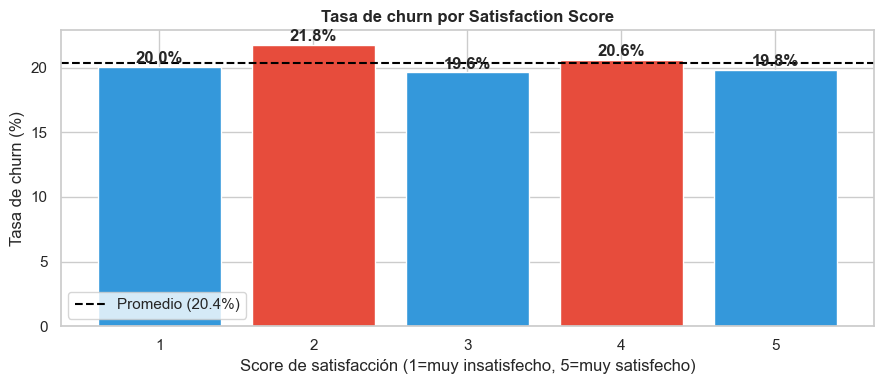

In [17]:
# Si el score de satisfacción es predictivo, debería haber diferencias claras entre grupos
churn_sat = df.groupby('Satisfaction Score')['Exited'].mean() * 100

plt.figure(figsize=(9, 4))
bars = plt.bar(churn_sat.index.astype(str), churn_sat.values,
               color=['#e74c3c' if v > df['Exited'].mean() * 100 else '#3498db'
                      for v in churn_sat.values],
               edgecolor='white')
plt.axhline(df['Exited'].mean() * 100, color='black', linestyle='--',
            linewidth=1.5, label=f'Promedio ({df["Exited"].mean()*100:.1f}%)')
plt.title('Tasa de churn por Satisfaction Score', fontweight='bold')
plt.xlabel('Score de satisfacción (1=muy insatisfecho, 5=muy satisfecho)')
plt.ylabel('Tasa de churn (%)')
plt.legend()
for bar, val in zip(bars, churn_sat.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Matriz de correlación

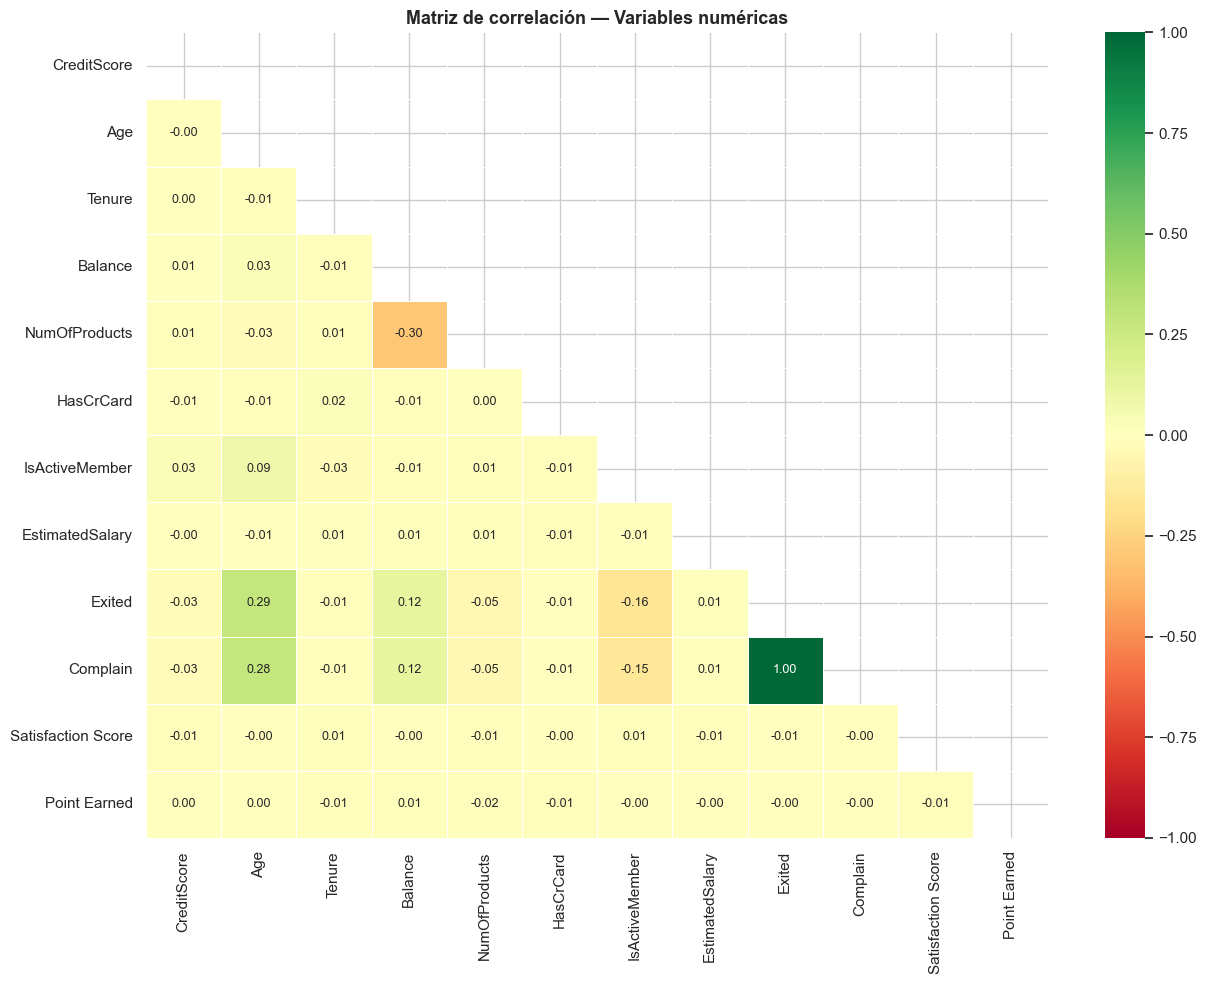

In [18]:
cols_num = df.select_dtypes(include=np.number).columns.tolist()
corr = df[cols_num].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Matriz de correlación — Variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

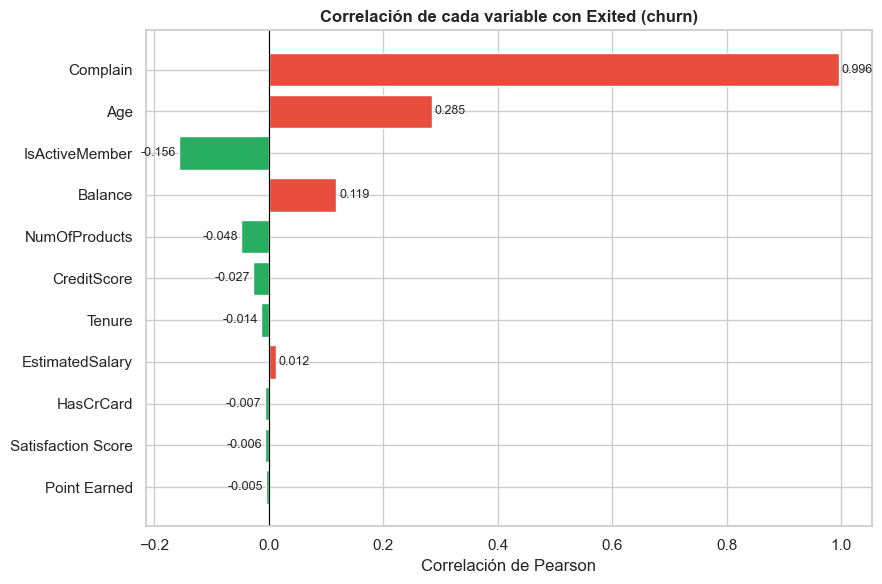

In [19]:
# Correlación individual con el target — ranking de poder predictivo
corr_target = df[cols_num].corr()['Exited'].drop('Exited').sort_values(key=abs, ascending=True)

colors = ['#e74c3c' if v > 0 else '#27ae60' for v in corr_target.values]

plt.figure(figsize=(9, 6))
bars = plt.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de cada variable con Exited (churn)', fontweight='bold')
plt.xlabel('Correlación de Pearson')
for bar, val in zip(bars, corr_target.values):
    offset = 0.005 if val >= 0 else -0.005
    plt.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Análisis cruzado: País × Género × Churn

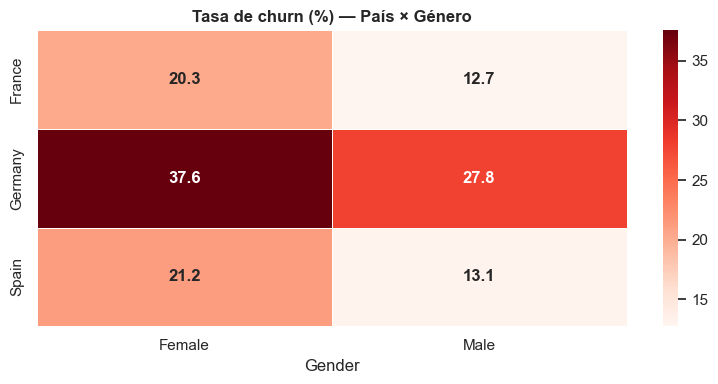


Segmento con mayor churn:
  País: Germany, Género: Female → 37.6%


In [20]:
# Cruzamos país y género para detectar segmentos de alto riesgo combinado
pivot = df.pivot_table(values='Exited', index='Geography',
                        columns='Gender', aggfunc='mean') * 100

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Tasa de churn (%) — País × Género', fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

print('\nSegmento con mayor churn:')
idx_max = pivot.stack().idxmax()
print(f'  País: {idx_max[0]}, Género: {idx_max[1]} → {pivot.stack().max():.1f}%')

## 11. Balance de cuenta vs Churn

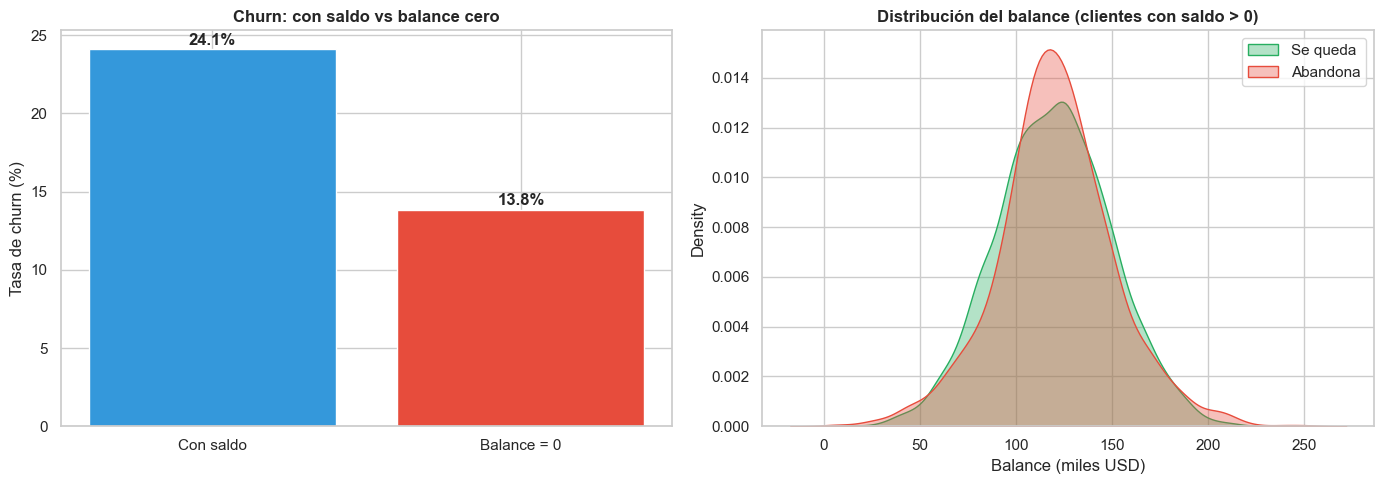

In [21]:
# El balance tiene una particularidad: muchos clientes tienen balance = 0
# Analizamos si eso es una señal de churn
df['balance_cero'] = (df['Balance'] == 0).astype(int)
churn_balance0 = df.groupby('balance_cero')['Exited'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clientes con balance 0 vs con saldo
axes[0].bar(['Con saldo', 'Balance = 0'], churn_balance0.values,
            color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('Churn: con saldo vs balance cero', fontweight='bold')
axes[0].set_ylabel('Tasa de churn (%)')
for i, v in enumerate(churn_balance0.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Distribución del balance solo para clientes con saldo > 0
con_saldo = df[df['Balance'] > 0]
for val, color, label in [(0, '#27ae60', 'Se queda'), (1, '#e74c3c', 'Abandona')]:
    sns.kdeplot(con_saldo[con_saldo['Exited'] == val]['Balance'] / 1000,
                ax=axes[1], color=color, label=label, fill=True, alpha=0.35)
axes[1].set_title('Distribución del balance (clientes con saldo > 0)', fontweight='bold')
axes[1].set_xlabel('Balance (miles USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

df.drop(columns=['balance_cero'], inplace=True)

## 12. Resumen de hallazgos

In [22]:
tasa_global      = df['Exited'].mean() * 100
churn_germany    = df[df['Geography'] == 'Germany']['Exited'].mean() * 100
churn_female     = df[df['Gender'] == 'Female']['Exited'].mean() * 100
churn_inactive   = df[df['IsActiveMember'] == 0]['Exited'].mean() * 100
churn_complain   = df[df['Complain'] == 1]['Exited'].mean() * 100
churn_45_55      = df[df['Age'].between(46, 55)]['Exited'].mean() * 100
churn_3_prod     = df[df['NumOfProducts'] >= 3]['Exited'].mean() * 100

top5_corr = df[cols_num].corr()['Exited'].drop('Exited').abs().sort_values(ascending=False).head(5)

print('=' * 55)
print('       RESUMEN DE HALLAZGOS — EDA ch_records')
print('=' * 55)
print(f'  Tasa global de churn:              {tasa_global:.1f}%')
print(f'  Churn en Alemania:                 {churn_germany:.1f}%')
print(f'  Churn en mujeres:                  {churn_female:.1f}%')
print(f'  Churn en miembros inactivos:       {churn_inactive:.1f}%')
print(f'  Churn en clientes con queja:       {churn_complain:.1f}%')
print(f'  Churn en rango 46-55 años:         {churn_45_55:.1f}%')
print(f'  Churn con 3+ productos:            {churn_3_prod:.1f}%')
print('=' * 55)
print()
print('Top 5 variables más correlacionadas con Exited:')
for var, val in top5_corr.items():
    print(f'  {var:<25} {val:.3f}')

       RESUMEN DE HALLAZGOS — EDA ch_records
  Tasa global de churn:              20.4%
  Churn en Alemania:                 32.4%
  Churn en mujeres:                  25.1%
  Churn en miembros inactivos:       26.9%
  Churn en clientes con queja:       99.5%
  Churn en rango 46-55 años:         50.6%
  Churn con 3+ productos:            85.9%

Top 5 variables más correlacionadas con Exited:
  Complain                  0.996
  Age                       0.285
  IsActiveMember            0.156
  Balance                   0.119
  NumOfProducts             0.048
